# Fine sweep around 2.3 GHz

The earlier coarse 2-3 GHz sweep (1 MHz steps, wide analyzer span/RBW) wasn't fine enough to reliably reveal a narrow resonance -- it only found a marginal dip near 2.04 GHz. Zooming in around 2.3 GHz specifically with a narrow analyzer span/RBW to check for a resonance there.

Output power kept low (-20 dBm) throughout.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from hp8673h import HP8673H
from e4403b import E4403B
from frequency_sweep import frequency_sweep

In [2]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

CENTER_HZ = 2.3e9
SPAN_HZ = 50e6      # 2.275-2.325 GHz
STEP_HZ = 50e3       # 1001 points
POWER_DBM = -20

start_hz = CENTER_HZ - SPAN_HZ / 2
stop_hz = CENTER_HZ + SPAN_HZ / 2

sa.set_center_span(CENTER_HZ, SPAN_HZ)

HP8673H: connected
E4403B: connected


In [3]:
freqs_hz, power_dbm = frequency_sweep(
    gen, sa,
    start_hz=start_hz, stop_hz=stop_hz, step_hz=STEP_HZ,
    power_dbm=POWER_DBM,
)

gen.close()
sa.close()

print(f"{len(freqs_hz)} points collected")

1001 points collected


dip: 2.305700 GHz, -66.0 dBm
baseline (median of window): -59.5 dBm
dip depth vs window median: 6.5 dB
dip depth vs window max: 12.6 dB


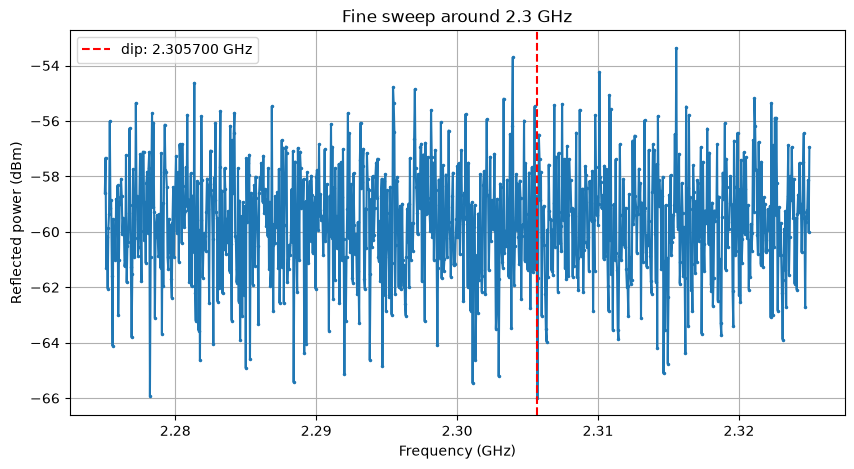

In [4]:
dip_idx = np.argmin(power_dbm)
resonance_freq = freqs_hz[dip_idx]
resonance_power = power_dbm[dip_idx]
baseline = np.median(power_dbm)

print(f"dip: {resonance_freq/1e9:.6f} GHz, {resonance_power:.1f} dBm")
print(f"baseline (median of window): {baseline:.1f} dBm")
print(f"dip depth vs window median: {baseline - resonance_power:.1f} dB")
print(f"dip depth vs window max: {power_dbm.max() - resonance_power:.1f} dB")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freqs_hz / 1e9, power_dbm, marker='.', markersize=3)
ax.axvline(resonance_freq / 1e9, color='r', linestyle='--',
           label=f'dip: {resonance_freq/1e9:.6f} GHz')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Fine sweep around 2.3 GHz")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
np.savetxt(
    "data/resonance_fine_sweep_2.3GHz.csv",
    np.column_stack((freqs_hz, power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)